In [5]:
import torch
from matplotlib import pyplot as plt
from whar_datasets.adapters.pytorch import PytorchAdapter
from whar_datasets.support.getter import WHARDatasetID, get_whar_cfg
from flow_matching.latent.training_ae import AETrainer
from flow_matching.whar.stft import istft_transform, plot_spectrogram_grid
from flow_matching.whar.models.ae import SpectrogramAE
from flow_matching.whar.ae_losses import ae_mse
from flow_matching.whar.stft import decompress_stft

In [6]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [4]:
cfg = get_whar_cfg(WHARDatasetID.UCI_HAR)
dataset = PytorchAdapter(cfg)

train_loader, val_loader, test_loader = dataset.get_dataloaders(
    train_batch_size=32, scv_group_index=0
)

num_classes = len(dataset.get_class_weights(train_loader))

Creating config hash...
Checking download...
Download exists.
Checking sessions...
Sessions exist.
Validating common format...
[########################################] | 100% Completed | 854.82 ms
Common format validated.
Checking windowing...
Loading config hash...
Windowing exists.
subject_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
activity_ids: [0 1 2 3 4 5]
train: 7201 | val: 801 | test: 1497
Postprocessing...


Loading windows: 100%|██████████| 9499/9499 [00:07<00:00, 1229.35it/s]


Getting normalization parameters...
Loading config hash...
Creating normalization parameters hash...
Loading normalization parameters hash...


Caching samples: 100%|██████████| 9499/9499 [00:01<00:00, 7685.44it/s]


In [11]:
ae = SpectrogramAE(in_channels=18, latent_channels=64)
trainer = AETrainer(
    model=ae,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=ae_mse,
    track=True,
)

In [12]:
trainer.train(num_epochs=30, device=device, lr=1e-3)

Training model with size: 7.812 MiB


100%|██████████| 1/1 [00:00<00:00,  1.50it/s]


Loss: 0.023, MSE: 0.085, Log Mag: 0.148, Log Mag Phase: 0.871, Spect Conv: 0.727


100%|██████████| 1/1 [00:00<00:00,  2.02it/s]


Loss: 0.022, MSE: 0.076, Log Mag: 0.141, Log Mag Phase: 0.834, Spect Conv: 0.678


...

Loss: 0.021, MSE: 0.057, Log Mag: 0.120, Log Mag Phase: 0.741, Spect Conv: 0.572


100%|██████████| 1/1 [00:00<00:00,  1.95it/s]


Loss: 0.022, MSE: 0.067, Log Mag: 0.131, Log Mag Phase: 0.743, Spect Conv: 0.631


Epoch 10, Loss: 0.017:  12%|█▏        | 27/226 [00:02<00:15, 12.44it/s]


KeyboardInterrupt: 

In [8]:
torch.save(ae.state_dict(), "cond_ae_24.pt")

In [ ]:
ae.load_state_dict(torch.load("cond_ae_24.pt"))

<All keys matched successfully>

tensor(-0.6741) tensor(0.9185)


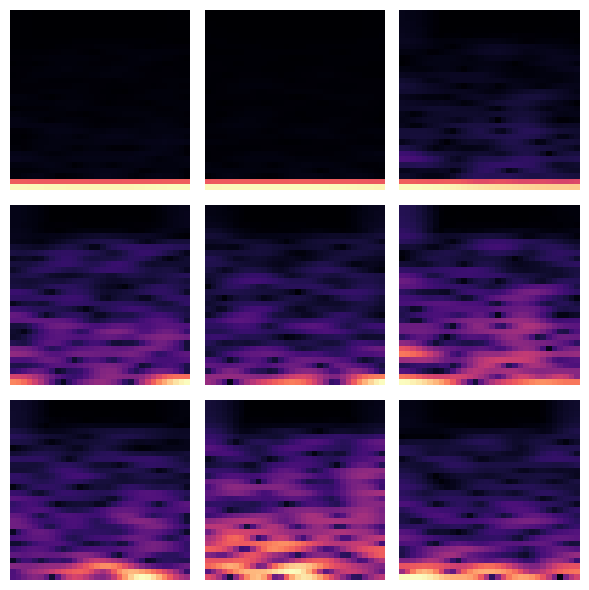

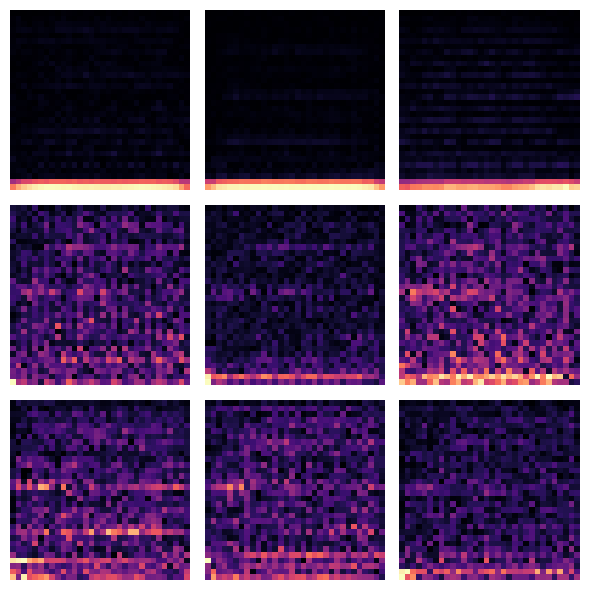

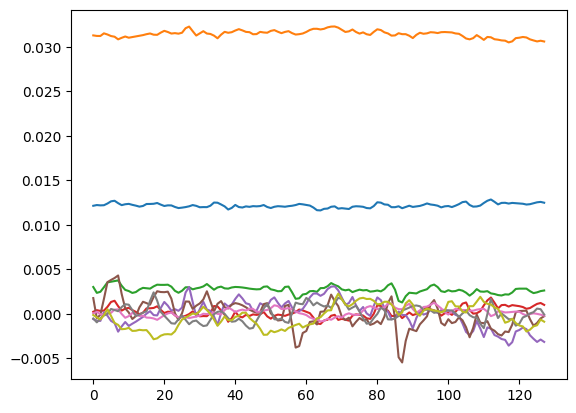

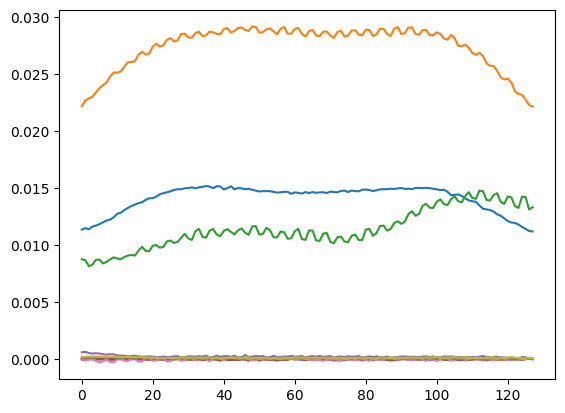

In [13]:
x, y = next(iter(train_loader))
out, z = ae(x.to(device))

B, C, H, W = out.shape
out = out.reshape(B, C // 2, 2, H, W)[0].detach().cpu()

print(out.min(), out.max())


plot_spectrogram_grid(x.reshape(B, C // 2, 2, H, W)[0])
plot_spectrogram_grid(out)


recon = istft_transform(decompress_stft(x.reshape(B, C // 2, 2, H, W)[0]))
plt.plot(recon)
plt.show()

recon = istft_transform(decompress_stft(out))
plt.plot(recon)
plt.show()